# Content Review 2

In [1]:
# Makes it so any variable or statement on it's own line gets printed w/o print()
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Start with importing the packages
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import altair as alt
import scipy.spatial as sp, scipy.cluster.hierarchy as hc
from   sklearn.preprocessing import StandardScaler

#pip install psynlig
#from psynlig import plot_correlation_heatmap


# Setting some visualization preferences
pd.set_option('display.precision', 2)
pd.set_option('display.max_columns',10)
#plt.style.use('seaborn-talk')

# We're also going to tell Jupyter to use inline plotting instead of notebook plotting
# It basically means you don't have to use plt.show() in every cell
%matplotlib inline

### Importing our datasets
We're going to start by importing data from the melanoma spreadsheet and the DESeq results, so that we've got something to work with.

In [4]:
# importing the melanoma dataset
melanoma_log2 = pd.read_excel('~/LECTURE_MATERIALS/DataFiles/melanoma_zerosRemoved_log2transformed_2026.xlsx',index_col = 0)
display(melanoma_log2)

,Sample_geo_accession,Stage,cell type,sample_number,cell_line,...,ZYX,ZZEF1,ZZZ3,BP-21201H5.1,BP-2189O9.2
Sample Title,,,,,,,,,,,
FM_1,GSM2344965,primary melanocytes,normal melanocytes,1,FM,...,11.66,11.83,10.55,3.17,1.00
FM_2,GSM2344966,primary melanocytes,normal melanocytes,2,FM,...,11.63,11.54,11.06,2.81,2.00
FM_3,GSM2344967,primary melanocytes,normal melanocytes,3,FM,...,12.31,11.44,10.81,2.32,1.58
SK_MEL_28_1,GSM2344968,metastatic,melanoma cell line,4,SK_MEL_28,...,11.86,10.94,11.64,0.00,6.04
SK_MEL_28_2,GSM2344969,metastatic,melanoma cell line,5,SK_MEL_28,...,11.97,11.03,11.74,1.00,6.41
SK_MEL_28_3,GSM2344970,metastatic,melanoma cell line,6,SK_MEL_28,...,11.94,11.02,11.59,0.00,5.91
SK_MEL_147_1,GSM2344971,metastatic,melanoma cell line,7,SK_MEL_147,...,13.09,11.19,12.29,5.21,5.21
SK_MEL_147_2,GSM2344972,metastatic,melanoma cell line,8,SK_MEL_147,...,13.14,11.11,12.28,5.04,5.09
SK_MEL_147_3,GSM2344973,metastatic,melanoma cell line,9,SK_MEL_147,...,13.00,11.12,11.77,5.13,5.39


In [3]:
# importing the DESeq2 analysis output
DESeqInfo = pd.read_csv('~/LECTURE_MATERIALS/DataFiles/deseq_results_melanoma.csv',index_col = 0)
DESeqInfo.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,374.70,-3.02e-06,1.21e-03,-0.96,0.34,0.50
A1CF,1.40,-4.24e-07,1.20e-03,-0.45,0.65,0.77
A2M,12905.71,-1.18e-06,1.73e-03,-1.49,0.14,0.26
A2ML1,4.96,-3.05e-06,1.27e-03,-1.85,0.06,0.15
A2MP1,7.87,-2.39e-06,1.81e-03,-2.35,0.02,0.06


### Prepping the data

We want to start with extracting the log2 count expression data of only the genes that have `padj < 0.05` and `abs(log2FoldChange) > 3.3` (to make the clustering less memory-intensive).

In [5]:
DESeqInfo.loc['A1BG','padj']

np.float64(0.4950610300493396)

In [12]:
DESeqInfo['padj'] < 0.05

A1BG            False
A1CF            False
A2M             False
A2ML1           False
A2MP1           False
                ...  
BP-2171C21.4    False
BP-2171C21.5    False
BP-2171C21.6     True
BP-2189O9.2      True
YR211F11.2      False
Name: padj, Length: 35238, dtype: bool

In [18]:
abs(DESeqInfo['log2FoldChange']) > 3.3

A1BG            False
A1CF            False
A2M             False
A2ML1           False
A2MP1           False
                ...  
BP-2171C21.4    False
BP-2171C21.5    False
BP-2171C21.6    False
BP-2189O9.2      True
YR211F11.2      False
Name: log2FoldChange, Length: 35238, dtype: bool

In [19]:
rowsofInterest = (DESeqInfo['padj'] < 0.05) & (abs(DESeqInfo['log2FoldChange']) > 3.3)

In [20]:
plow = DESeqInfo.loc[rowsofInterest,:]

In [21]:
plow[:5]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ABCA1,107.95,-4.52,0.74,-6.29,3.10e-10,7.35e-09
ABCB5,2028.67,-4.23,1.00,-4.54,5.66e-06,5.40e-05
ABCG4,36.69,-3.42,0.60,-6.01,1.84e-09,3.77e-08
AC009299.4,35.44,6.40,1.33,4.73,2.27e-06,2.40e-05
AC011933.2,2.20,-7.64,2.39,-4.47,7.69e-06,7.09e-05


In [22]:
plow.index

Index(['ABCA1', 'ABCB5', 'ABCG4', 'AC009299.4', 'AC011933.2', 'AC108938.5',
       'ACKR1', 'ACOT4', 'ACP7', 'ACSM5',
       ...
       'ZIC2', 'ZIC4', 'ZIC5', 'ZNF154', 'ZNF300P1', 'ZNF423', 'ZNF662',
       'ZNF853', 'ZSCAN12P1', 'BP-2189O9.2'],
      dtype='object', length=475)

In [25]:
overlappingGenes = list( set(plow.index) & set(melanoma_log2.columns) )
overlappingGenes

['WIPF3',
 'AIFM3',
 'FCGRT',
 'RBM47',
 'MYO15B',
 'FBLN1',
 'BCAN',
 'WFDC1',
 'CKB',
 'PLPP2',
 'SHC2',
 'LRRC2',
 'EFHD1',
 'CDH3',
 'PIK3IP1',
 'SEPT4',
 'PCDHGB7',
 'ANKRD18B',
 'GSTM1',
 'C15ORF59',
 'LIMS2',
 'FHAD1',
 'PINLYP',
 'CYP2U1',
 'RPL23AP1',
 'ELOVL2',
 'FREM2',
 'ULBP2',
 'CERS4',
 'SERPINB9',
 'FRMD3',
 'GALNTL6',
 'APOE',
 'IGFBP3',
 'SLC18B1',
 'PRAME',
 'NEFH',
 'SEMA3D',
 'CTF1',
 'PNMAL1',
 'PTPRB',
 'CASZ1',
 'STON2',
 'RND2',
 'CNNM1',
 'ODF3B',
 'BP-2189O9.2',
 'RPL39P5',
 'GSG1L',
 'ZNF853',
 'TCERG1L',
 'PCDHGA11',
 'NRXN3',
 'BX004987.1',
 'PRKY',
 'CCDC8',
 'HLA-K',
 'DUXAP9',
 'B3GALT4',
 'PLEKHA6',
 'ABCA1',
 'HHIPL1',
 'CADPS',
 'CA14',
 'RP11-848P1.9',
 'ASPA',
 'EMB',
 'ULBP3',
 'NUDT10',
 'LRRC6',
 'KCNE4',
 'CTSF',
 'SHF',
 'MALL',
 'MANEAL',
 'SUSD1',
 'CCDC171',
 'C11ORF96',
 'ELOVL7',
 'MFAP2',
 'AEBP1',
 'EMCN',
 'SFRP1',
 'DYSF',
 'PGBD5',
 'ACP7',
 'HOXB9',
 'CACNA1A',
 'LRRC39',
 'LIPE',
 'GIPC3',
 'PRCD',
 'CRYL1',
 'NECAB2',
 'AIM2',
 'R

In [26]:
melanoma_log2GOI = melanoma_log2.loc[:,overlappingGenes]

In [27]:
display(melanoma_log2GOI)

,WIPF3,AIFM3,FCGRT,RBM47,MYO15B,...,USP51,CREB5,SALL4,CHADL,GPRIN3
Sample Title,,,,,,,,,,,
FM_1,10.25,5.91,11.85,3.81,8.41,...,9.01,6.95,10.03,7.12,11.16
FM_2,9.95,6.21,10.89,4.52,6.67,...,9.05,6.00,9.65,6.23,11.12
FM_3,9.72,6.49,11.99,3.46,8.54,...,8.53,6.75,9.56,8.06,10.43
SK_MEL_28_1,4.25,2.32,3.17,9.35,1.58,...,5.39,7.99,3.17,2.81,4.86
SK_MEL_28_2,3.17,3.17,1.00,9.61,3.17,...,5.29,8.36,2.81,1.00,5.55
SK_MEL_28_3,2.81,4.17,1.58,9.71,2.32,...,5.55,8.55,1.00,3.32,5.32
SK_MEL_147_1,2.81,1.00,7.60,4.64,4.17,...,6.29,11.46,3.91,1.00,4.32
SK_MEL_147_2,3.46,2.00,7.39,4.09,4.46,...,6.19,11.22,4.58,2.32,4.25
SK_MEL_147_3,1.58,2.58,8.93,4.25,5.09,...,6.52,11.65,5.46,2.32,4.58


In [ ]:
#find genes with padj < 0.05 and abs(log2FoldChange) > 3.3
sigGenes = DESeqInfo.index[ (DESeqInfo['padj'] < 0.05) & ( abs(DESeqInfo['log2FoldChange']) > 3.3 ) ]

#find overlap between sigGenes and genes in melanoma_log2
GOI = list( set(sigGenes) & set(melanoma_log2.columns))

In [ ]:
melanoma_log2_DEGexp = melanoma_log2.loc[:,GOI]
display(melanoma_log2_DEGexp)

## Calculating hierarchical clustering dendrograms

For maximum flexibility, you can perform own distance and linkage calculations separately and generate dendrograms separately. 

The workflow for generating dendrograms for a matrix is:

0. (optional) Standard scale the data. This ensure that all features contribute equally to the distance calculations
1. Calculate the distance betwen each pair of vectors within the matrix.
2. Calculate linkage with `scipy.cluster.hierarchy` (which we have nicknamed the alias `hc`).
3. Draw dendrograms

We will demonstrate this workflow by calculating dendrograms clustering the samples from `melanoma_log2_DEGexp` with Euclidean distance and Pearson distance.

### Step 0: Standard scaling

In [28]:
melanoma_log2_DEGexp = melanoma_log2GOI

In [31]:
display(melanoma_log2_DEGexp)

,WIPF3,AIFM3,FCGRT,RBM47,MYO15B,...,USP51,CREB5,SALL4,CHADL,GPRIN3
Sample Title,,,,,,,,,,,
FM_1,10.25,5.91,11.85,3.81,8.41,...,9.01,6.95,10.03,7.12,11.16
FM_2,9.95,6.21,10.89,4.52,6.67,...,9.05,6.00,9.65,6.23,11.12
FM_3,9.72,6.49,11.99,3.46,8.54,...,8.53,6.75,9.56,8.06,10.43
SK_MEL_28_1,4.25,2.32,3.17,9.35,1.58,...,5.39,7.99,3.17,2.81,4.86
SK_MEL_28_2,3.17,3.17,1.00,9.61,3.17,...,5.29,8.36,2.81,1.00,5.55
SK_MEL_28_3,2.81,4.17,1.58,9.71,2.32,...,5.55,8.55,1.00,3.32,5.32
SK_MEL_147_1,2.81,1.00,7.60,4.64,4.17,...,6.29,11.46,3.91,1.00,4.32
SK_MEL_147_2,3.46,2.00,7.39,4.09,4.46,...,6.19,11.22,4.58,2.32,4.25
SK_MEL_147_3,1.58,2.58,8.93,4.25,5.09,...,6.52,11.65,5.46,2.32,4.58


In [29]:
#The mean of each gene expression is set to 0 and the standard deviation to 1
melanoma_scaled = StandardScaler().fit_transform(melanoma_log2_DEGexp)
display(melanoma_scaled)

array([[ 1.7727673 ,  1.39632019,  1.42486676, ...,  1.71579955,
         1.37258437,  1.75014389],
       [ 1.66973388,  1.54791324,  1.20135688, ...,  1.58576792,
         0.9716539 ,  1.73243599],
       [ 1.59391085,  1.689404  ,  1.45609247, ...,  1.55480005,
         1.79677124,  1.45880488],
       ...,
       [-0.18440459, -1.06217961, -0.95889003, ..., -0.34019147,
         0.33139571,  0.08585109],
       [-0.44092536, -0.7690958 , -1.0947126 , ..., -0.68111412,
         0.28323878, -0.21649439],
       [-0.37114999, -1.06217961, -0.95889003, ..., -0.74679119,
         0.49470516, -0.24865246]], shape=(12, 197))

In [30]:
melanoma_scaledDF = pd.DataFrame(melanoma_scaled)
melanoma_scaledDF.describe()

,0,1,2,3,4,...,192,193,194,195,196
count,1.20e+01,1.20e+01,1.20e+01,1.20e+01,1.20e+01,...,1.20e+01,1.20e+01,1.20e+01,1.20e+01,1.20e+01
mean,2.96e-16,1.85e-16,-2.31e-16,1.02e-16,3.61e-16,...,-3.15e-16,-2.04e-16,-7.40e-17,9.25e-18,3.49e-16
std,1.04e+00,1.04e+00,1.04e+00,1.04e+00,1.04e+00,...,1.04e+00,1.04e+00,1.04e+00,1.04e+00,1.04e+00
min,-1.16e+00,-1.06e+00,-1.09e+00,-1.25e+00,-1.38e+00,...,-1.46e+00,-1.60e+00,-1.36e+00,-1.38e+00,-9.85e-01
25%,-6.51e-01,-8.42e-01,-9.59e-01,-9.43e-01,-7.18e-01,...,-5.48e-01,-8.15e-01,-6.98e-01,-7.88e-01,-7.70e-01
50%,-4.06e-01,-3.34e-01,-1.01e-01,-7.12e-02,-1.23e-01,...,-1.09e-01,1.64e-01,-3.56e-01,-2.72e-02,-3.58e-01
75%,2.60e-01,7.44e-01,8.61e-01,8.77e-01,4.15e-01,...,5.03e-01,9.25e-01,5.07e-01,6.14e-01,4.29e-01
max,1.77e+00,1.69e+00,1.46e+00,1.29e+00,1.82e+00,...,1.58e+00,1.09e+00,1.72e+00,1.80e+00,1.75e+00


#### Step 1: calculating distance

There are multiple ways to calculate distance. The `scipy.spatial` library has many different distance computations implemented, which is described [here](https://docs.scipy.org/doc/scipy/reference/spatial.distance.html). The easiest way to toggle between distance metrics is to use the `scipy.spatial.distance` function `pdist()` and toggling `metric` argument

For example, you can calculate the Euclidean distance between a pair of vectors with the `sp.distance` function `pdist()` with the `metric = 'euclidean'` argument.

Note: here, we are using the `sp.distance.squareform` function to visualize the pairwise distances as a full matrix.

In [32]:
edist = sp.distance.pdist(melanoma_scaled,metric = 'euclidean')
display(sp.distance.squareform(edist))

array([[ 0.        ,  6.44659383,  7.38317366, 30.49486396, 30.2921559 ,
        30.30136466, 32.00507987, 32.27080037, 30.79674544, 28.97530574,
        31.46261635, 31.1964159 ],
       [ 6.44659383,  0.        ,  7.2803093 , 29.52031233, 29.27449835,
        29.33256614, 31.05142016, 31.42734489, 30.08251923, 28.13963119,
        30.54761123, 30.34398692],
       [ 7.38317366,  7.2803093 ,  0.        , 29.54786814, 29.15811351,
        29.22659234, 30.67730775, 31.08901303, 29.65980714, 27.70156488,
        30.13319935, 29.8423636 ],
       [30.49486396, 29.52031233, 29.54786814,  0.        ,  4.23491792,
         4.58150304, 11.87371253, 11.9158395 , 12.73506676, 10.5474919 ,
        10.11320721, 10.14666454],
       [30.2921559 , 29.27449835, 29.15811351,  4.23491792,  0.        ,
         4.12020211, 11.55736337, 11.62890414, 12.26966838, 10.2223638 ,
         9.87059558, 10.02000068],
       [30.30136466, 29.33256614, 29.22659234,  4.58150304,  4.12020211,
         0.        , 1

For example, you can calculate the Pearson correlation distance between a pair of vectors with the `scipy.spatial.distance` function `pdist()` with the `metric = 'correlation'` argument.

In [33]:
corrdist = sp.distance.pdist(melanoma_scaled,metric = 'correlation')
display(sp.distance.squareform(corrdist))

array([[0.        , 0.04860714, 0.06626911, 1.62669611, 1.66584218,
        1.64311632, 1.72312787, 1.7120193 , 1.629499  , 1.69026903,
        1.77923766, 1.7719107 ],
       [0.04860714, 0.        , 0.0664    , 1.61947713, 1.64818729,
        1.63375185, 1.71518678, 1.72300012, 1.65264224, 1.69231761,
        1.77327766, 1.77569882],
       [0.06626911, 0.0664    , 0.        , 1.65997848, 1.66887811,
        1.6560115 , 1.69645639, 1.7065036 , 1.63361662, 1.6777886 ,
        1.75643367, 1.74488383],
       [1.62669611, 1.61947713, 1.65997848, 0.        , 0.12165886,
        0.13893178, 0.81273956, 0.81637342, 0.9042677 , 0.68805615,
        0.59316404, 0.60908823],
       [1.66584218, 1.64818729, 1.66887811, 0.12165886, 0.        ,
        0.1171495 , 0.77379105, 0.77470875, 0.85644503, 0.68661767,
        0.58206598, 0.61381853],
       [1.64311632, 1.63375185, 1.6560115 , 0.13893178, 0.1171495 ,
        0.        , 0.83358397, 0.80061127, 0.88630276, 0.66057558,
        0.58315013,

You can also calculate a correlation based distance by subtracting 1 - the absolute value of the correlation coefficients.

In [34]:
1 - np.corrcoef(melanoma_scaled)

array([[0.00000000e+00, 4.86071426e-02, 6.62691081e-02, 1.62669611e+00,
        1.66584218e+00, 1.64311632e+00, 1.72312787e+00, 1.71201930e+00,
        1.62949900e+00, 1.69026903e+00, 1.77923766e+00, 1.77191070e+00],
       [4.86071426e-02, 0.00000000e+00, 6.64000033e-02, 1.61947713e+00,
        1.64818729e+00, 1.63375185e+00, 1.71518678e+00, 1.72300012e+00,
        1.65264224e+00, 1.69231761e+00, 1.77327766e+00, 1.77569882e+00],
       [6.62691081e-02, 6.64000033e-02, 0.00000000e+00, 1.65997848e+00,
        1.66887811e+00, 1.65601150e+00, 1.69645639e+00, 1.70650360e+00,
        1.63361662e+00, 1.67778860e+00, 1.75643367e+00, 1.74488383e+00],
       [1.62669611e+00, 1.61947713e+00, 1.65997848e+00, 2.22044605e-16,
        1.21658858e-01, 1.38931777e-01, 8.12739564e-01, 8.16373419e-01,
        9.04267705e-01, 6.88056152e-01, 5.93164044e-01, 6.09088228e-01],
       [1.66584218e+00, 1.64818729e+00, 1.66887811e+00, 1.21658858e-01,
        0.00000000e+00, 1.17149505e-01, 7.73791053e-01, 7.74

### Step 2: Calculate linkage

Once we have the distance, we can calculate the linkage (the calculation of the horizontal bars) using the `hc.linkage()` function. The linkage function will accept as input a variable with the pairwise distances (in a condensed format) and will output an array that contains the clustering information (which groups are clustered and what the height of the bar is)

In [35]:
edist

array([ 6.44659383,  7.38317366, 30.49486396, 30.2921559 , 30.30136466,
       32.00507987, 32.27080037, 30.79674544, 28.97530574, 31.46261635,
       31.1964159 ,  7.2803093 , 29.52031233, 29.27449835, 29.33256614,
       31.05142016, 31.42734489, 30.08251923, 28.13963119, 30.54761123,
       30.34398692, 29.54786814, 29.15811351, 29.22659234, 30.67730775,
       31.08901303, 29.65980714, 27.70156488, 30.13319935, 29.8423636 ,
        4.23491792,  4.58150304, 11.87371253, 11.9158395 , 12.73506676,
       10.5474919 , 10.11320721, 10.14666454,  4.12020211, 11.55736337,
       11.62890414, 12.26966838, 10.2223638 ,  9.87059558, 10.02000068,
       12.11099538, 11.93875871, 12.59908472, 10.15712355,  9.97337399,
       10.0547439 ,  4.29470163,  5.7497422 , 11.40784825, 11.08860502,
       10.82176499,  5.47343495, 11.77567033, 11.29787654, 11.13392848,
       11.4140581 , 11.82188834, 11.60156258,  5.3036861 ,  5.42914776,
        4.37147964])

In [36]:
sampleLinkage = hc.linkage(edist, method='average')
display(sampleLinkage)

array([[ 4.        ,  5.        ,  4.12020211,  2.        ],
       [ 6.        ,  7.        ,  4.29470163,  2.        ],
       [10.        , 11.        ,  4.37147964,  2.        ],
       [ 3.        , 12.        ,  4.40821048,  3.        ],
       [ 9.        , 14.        ,  5.36641693,  3.        ],
       [ 8.        , 13.        ,  5.61158858,  3.        ],
       [ 0.        ,  1.        ,  6.44659383,  2.        ],
       [ 2.        , 18.        ,  7.33174148,  3.        ],
       [15.        , 16.        , 10.12284057,  6.        ],
       [17.        , 20.        , 11.7218109 ,  9.        ],
       [19.        , 21.        , 30.16855809, 12.        ]])

### Step 3: visualize dendrogram

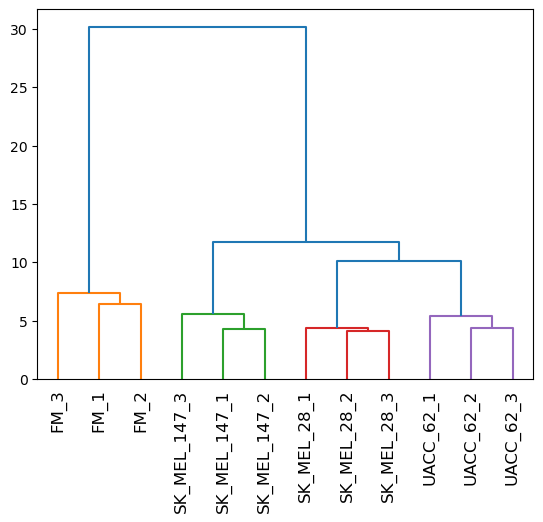

In [37]:
threshold = 10
hc.dendrogram(sampleLinkage, labels=melanoma_log2_DEGexp.index, leaf_rotation=90,color_threshold = threshold);


### Downstream analysis after clustering:

You can define bins (clusters) based on a desired threshold. 
You can also output information about which bin each sample belongs to, you can use the `fcluster()` function:

In [38]:
# Clusterize the data
SampleClusterLabels = hc.fcluster(sampleLinkage, threshold, criterion='distance')

# Show the cluster
sampleClusterInfo = pd.DataFrame({'samples': melanoma_log2.index,'cluster_labels': SampleClusterLabels})
sampleClusterInfo

,samples,cluster_labels
0,FM_1,1
1,FM_2,1
2,FM_3,1
3,SK_MEL_28_1,3
4,SK_MEL_28_2,3
5,SK_MEL_28_3,3
6,SK_MEL_147_1,2
7,SK_MEL_147_2,2
8,SK_MEL_147_3,2
9,UACC_62_1,4


## <font color=blue>Bonus: Intro to `scanpy`

The `scanpy` package allows easy to use single cell data analyses in Python. It has a large array of built in functions for different analyses (data pre-processing, visualization, clustering, trajectory etc).

**Resources:**
*   https://genomebiology.biomedcentral.com/articles/10.1186/s13059-017-1382-0
*   https://scanpy.readthedocs.io/en/stable/

To demonstrate, let's examine a popular single cell RNA seq data set of human PBMC samples, used for the [SCANPy tutorial](https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html) and by others (10X genomics):
**pbmc_data_master.h5ad**


We will now use `scanpy` which we loaded as sc, and use tSNE and UMAP visualize the single cell PBMC data in 2D.





In [39]:
import scanpy as sc
import anndata as ad

In [40]:
#Read sc PBMC file to be used for scanpy

pbmc_file = "pbmc_data_master.h5ad"

pbmc_scrnaseq = sc.read_h5ad(pbmc_file)

In [41]:
# setting up a new results file to save data into
results_file = "dat_mod.h5ad"

Note: `scanpy` functions are divided into 3 categories: preprocessing (labeled as `pp`), analysis tools (labeled as `tl`), and plotting (labeled as `pl`).

### Running PCA

In [42]:
# Compute PCA to determine the default number of components
sc.tl.pca(pbmc_scrnaseq, svd_solver="arpack")

pbmc_scrnaseq.write(results_file)

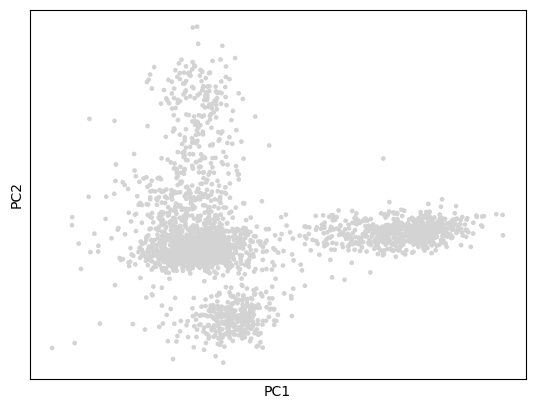

In [43]:
#plotting the PCA
sc.pl.pca(pbmc_scrnaseq)

Each dot represents a different cell profiled in the dataset. You can see by eye that the data appear to form separate clusters (perhaps explained by cell type similarities in expression).

Besides plotting the PC visualization, you can also plot the variance explained

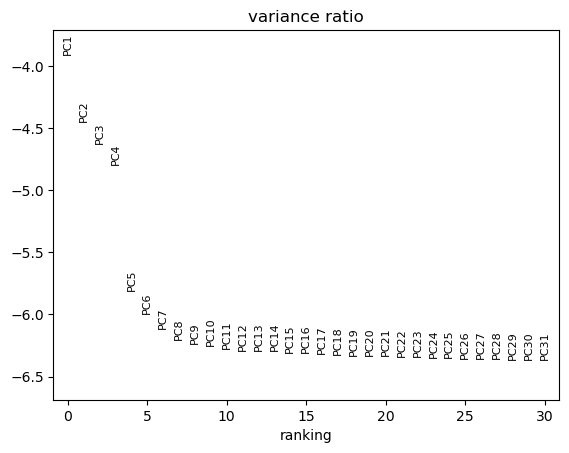

In [44]:
#plotting the PC variance explained
sc.pl.pca_variance_ratio(pbmc_scrnaseq, log=True)

### Clustering analysis
The recommended clustering method for scRNA-seq is the Leiden graph-clustering method (community detection based on optimizing modularity) [Traag et al., 2019](https://www.nature.com/articles/s41598-019-41695-z). Note that Leiden clustering directly clusters a neighborhood graph of cells.

First, we need to calculate nearest neighbors. This can be done with the `pp.neighbors()` function:

In [45]:
#compute neighbors
#n_neighbors and n_pcs can be modified

sc.pp.neighbors(pbmc_scrnaseq, n_neighbors=10, n_pcs=40)

The Leiden clustering then uses the nearest neighbor distances calculated by `pp.neighbors()` to detect clusters.

In [46]:
# Compute Leiden clustering

sc.tl.leiden(
    pbmc_scrnaseq,
    resolution=0.9, #impact clusters
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)

Now, we can update the PCA visualization with the clusters computed by the Leiden method

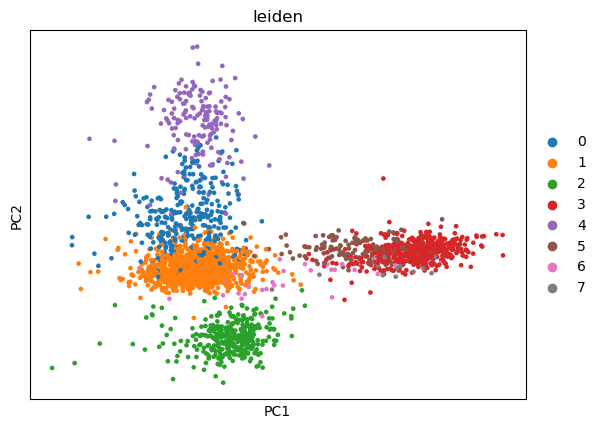

In [47]:
#plotting the PCA
sc.pl.pca(pbmc_scrnaseq, color = "leiden")

Note that because we performed the analysis on the `pbmc_scrnaseq` object, that object has been updated with the computed clusters.

Now, let's look at how the cells cluster by t-SNE and UMAP

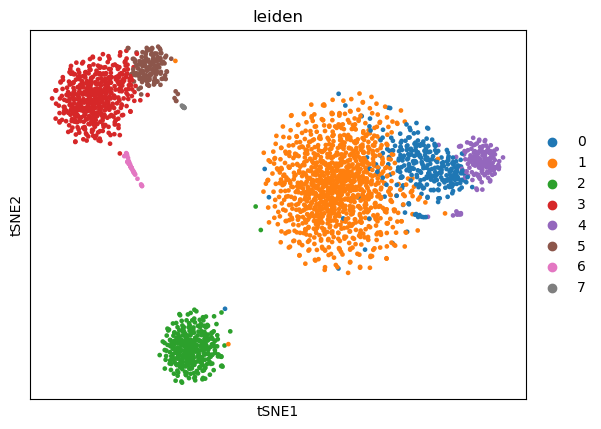

In [48]:
#tSNE

#run tSNE
sc.tl.tsne(pbmc_scrnaseq, perplexity = 40)

#plot tSNE
sc.pl.tsne(pbmc_scrnaseq, color=["leiden"])

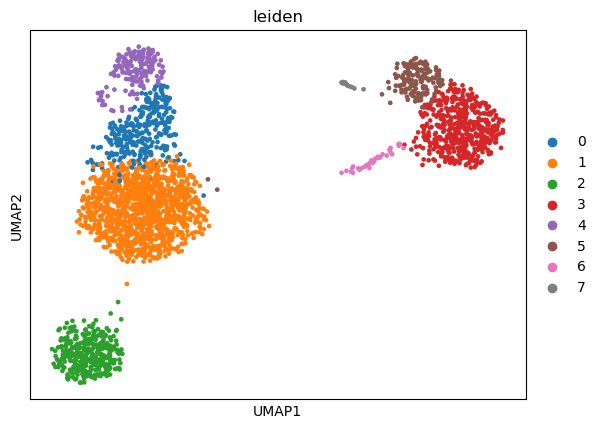

In [49]:
# UMAP
# Run UMAP
sc.tl.umap(pbmc_scrnaseq)

# Plot UMAP
sc.pl.umap(pbmc_scrnaseq, color=["leiden"])

We can find which genes express differently between the different Leiden clusters with `rank_genes_groups()`.

*Note:* According to the `scanpy` documentation, comparing between cells leads to highly inflated p-values, since cells are not independent observations [Squair et al., 2021]. Especially in single-cell data, consider instead to use more appropriate methods such as combining pseudobulking with `PyDESeq2` documentation.

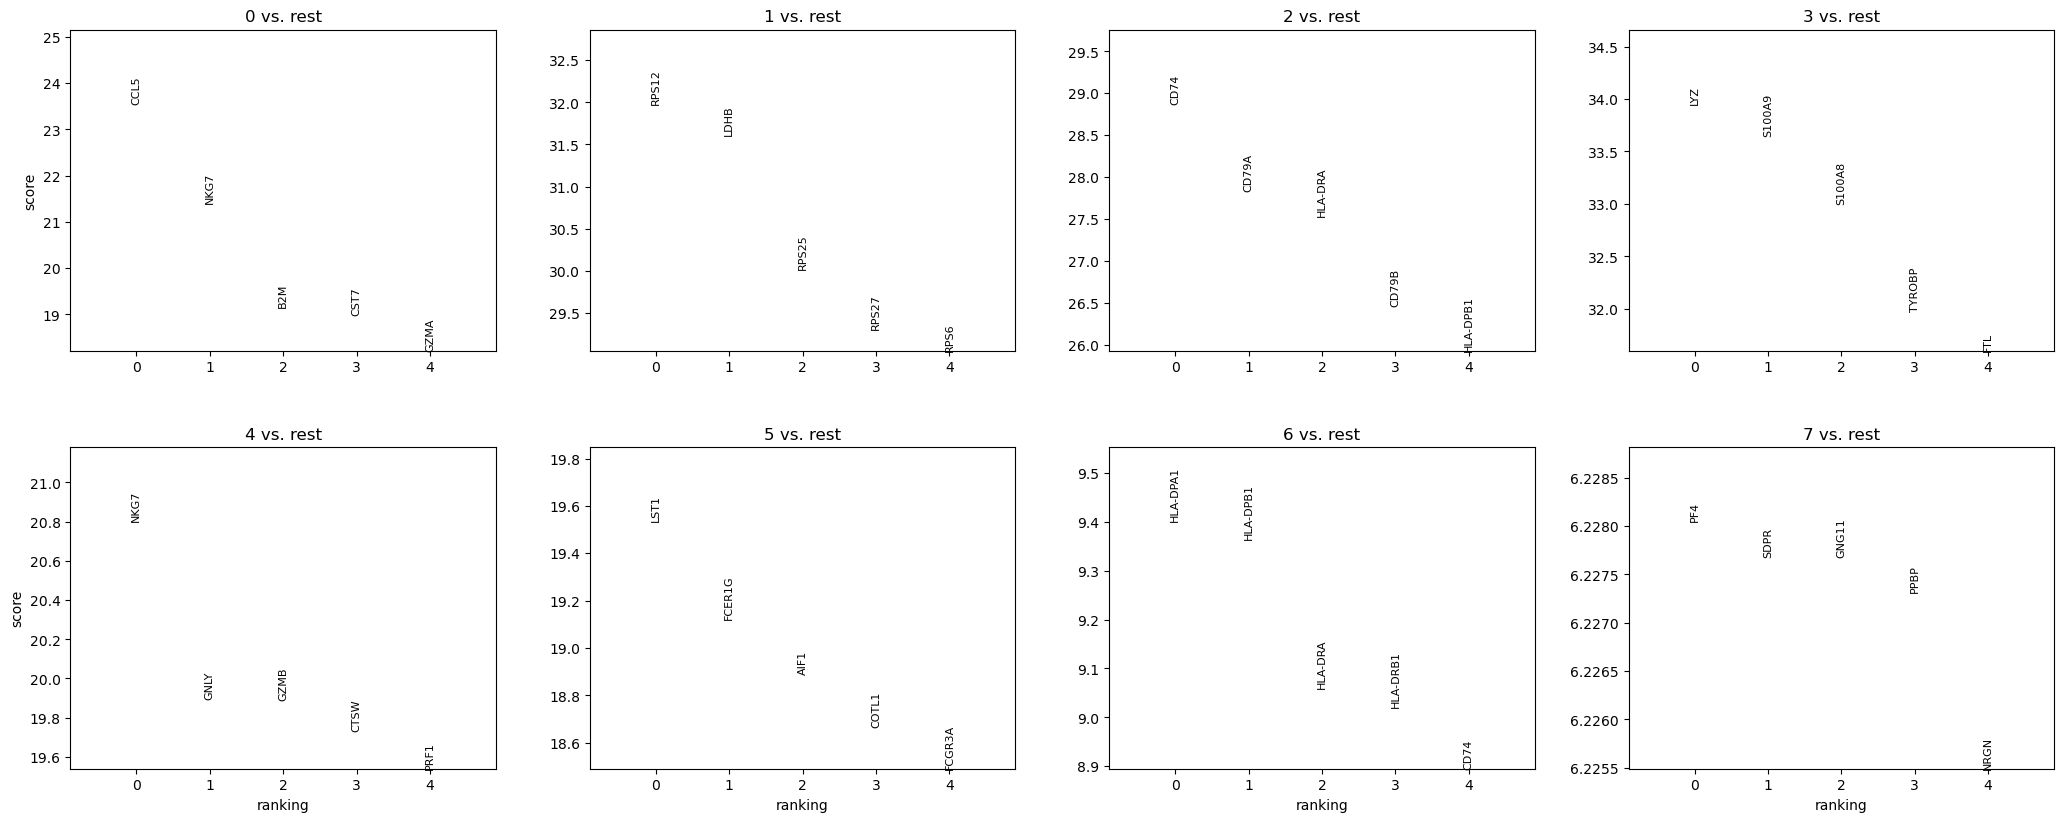

In [50]:
#finding marker genes

sc.tl.rank_genes_groups(pbmc_scrnaseq, "leiden", method="wilcoxon")

sc.pl.rank_genes_groups(pbmc_scrnaseq, n_genes=5, sharey=False) #graphing top 5 genes in each cluster

In [53]:
pd.DataFrame(pbmc_scrnaseq.uns["rank_genes_groups"]["names"]).head(10)

,0,1,2,3,4,5,6,7
0,CCL5,RPS12,CD74,LYZ,NKG7,LST1,HLA-DPA1,PF4
1,NKG7,LDHB,CD79A,S100A9,GNLY,FCER1G,HLA-DPB1,SDPR
2,B2M,RPS25,HLA-DRA,S100A8,GZMB,AIF1,HLA-DRA,GNG11
3,CST7,RPS27,CD79B,TYROBP,CTSW,COTL1,HLA-DRB1,PPBP
4,GZMA,RPS6,HLA-DPB1,FTL,PRF1,FCGR3A,CD74,NRGN
5,IL32,RPS3,MS4A1,FCN1,GZMA,FTH1,HLA-DQA1,SPARC
6,CTSW,RPS14,HLA-DQA1,CST3,CST7,IFITM2,CST3,GPX1
7,HLA-C,RPL31,CD37,S100A6,HLA-C,IFITM3,FCER1A,TPM4
8,HLA-A,CD3D,HLA-DRB1,FTH1,B2M,SAT1,HLA-DRB5,RGS18
9,GZMK,RPL3,HLA-DQB1,LGALS2,FGFBP2,PSAP,HLA-DMA,CALM3


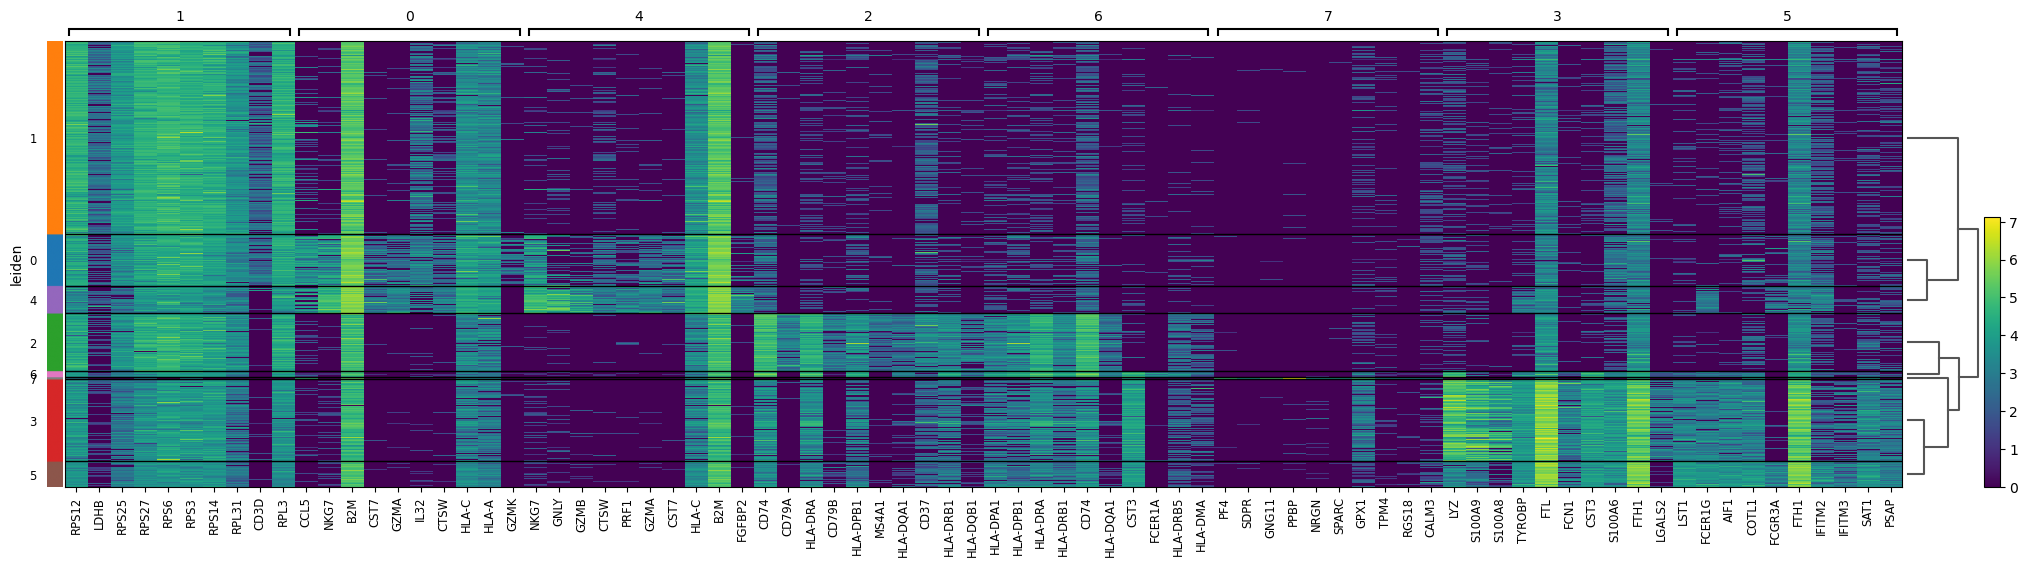

In [52]:
sc.pl.rank_genes_groups_heatmap(pbmc_scrnaseq, n_genes=10, groupby = "leiden", show_gene_labels=True) #graphing by heatmap top ten genes in each cluster

In [54]:
pbmc_scrnaseq.write(results_file)

### Examining known genes of interest
You can overlay the expression levels of genes of interest onto the different clusters

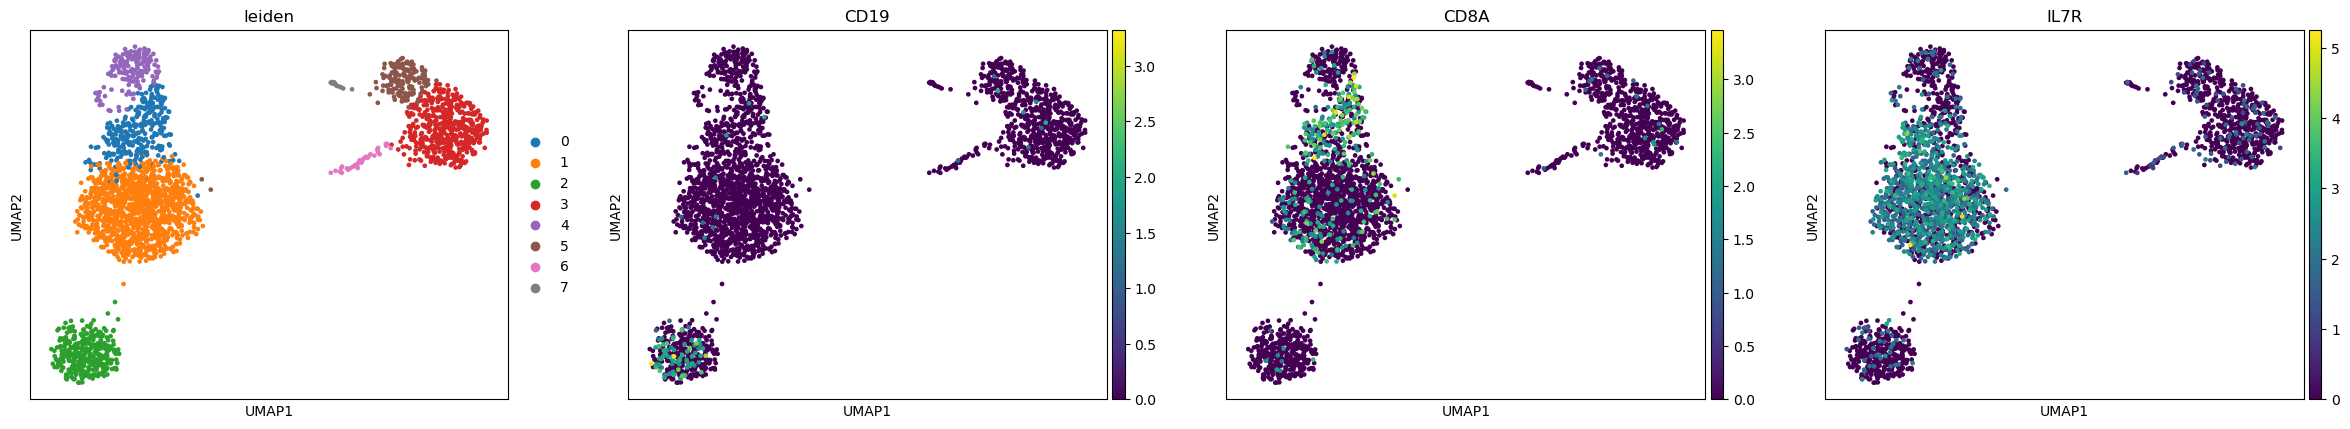

In [55]:
#Find and pull put expression of one gene

sc.pl.umap(pbmc_scrnaseq, color=["leiden", "CD19", "CD8A", "IL7R"])

In [56]:
#define marker genes
marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD8A", "CD8B", "LYZ", "CD14", "CD4"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]

In [57]:
marker_genes

['IL7R',
 'CD79A',
 'MS4A1',
 'CD8A',
 'CD8B',
 'LYZ',
 'CD14',
 'CD4',
 'LGALS3',
 'S100A8',
 'GNLY',
 'NKG7',
 'KLRB1',
 'FCGR3A',
 'MS4A7',
 'FCER1A',
 'CST3',
 'PPBP']

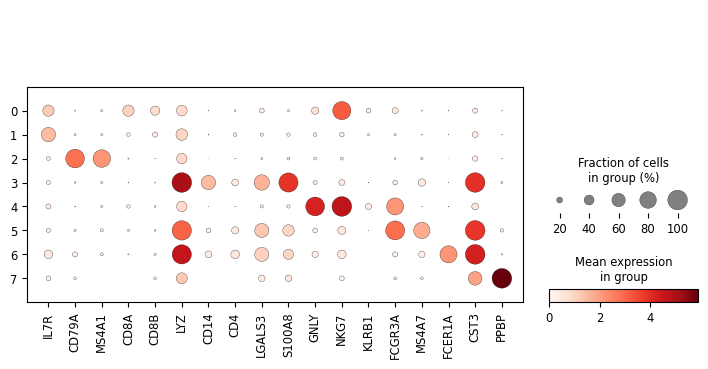

In [58]:
sc.pl.dotplot(pbmc_scrnaseq, marker_genes, groupby="leiden");

You can redefine the cluster labels based on the expression profiles of these known genes-of-interest

In [59]:
# Cluster by cell type

new_cluster_names = [
    "CD4 T",
    "B",
    "FCGR3A+ Monocytes",
    "NK",
    "CD8 T",
    "CD14+ Monocytes",
    "Dendritic",
    "Megakaryocytes",
]

pbmc_scrnaseq.rename_categories("leiden", new_cluster_names)


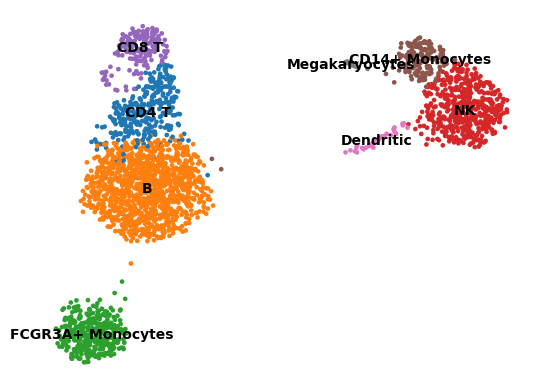

In [60]:
sc.pl.umap(
    pbmc_scrnaseq, color="leiden", legend_loc="on data", title="", frameon=False)

## Clustering T-cells, NK cells and B-cells

If we are interested in identifying the heterogeneity within the T- and T-cell like populations, based on the assigned cluster labels from above, we can use that to subset out the cells within that cluster and repeat the clustering and UMAP on the new dataset.

In [61]:
#subset out clusters of interest
subset_pbmc_scrnaseq = pbmc_scrnaseq[pbmc_scrnaseq.obs['leiden'].isin(['CD8 T', 'CD4 T', 'NK', 'B'])]

In [62]:
#calculate PCA for the new subsetted data
sc.tl.pca(subset_pbmc_scrnaseq, svd_solver="arpack")

/opt/conda/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


In [63]:
#compute neighbors
sc.pp.neighbors(subset_pbmc_scrnaseq, n_neighbors=15, n_pcs=40)
subset_pbmc_scrnaseq

AnnData object with n_obs × n_vars = 2098 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'leiden', 'leiden_colors', 'tsne', 'umap', 'rank_genes_groups', 'dendrogram_leiden'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [64]:
#perform leiden clustering

sc.tl.leiden(
    subset_pbmc_scrnaseq,
    resolution=0.9,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)

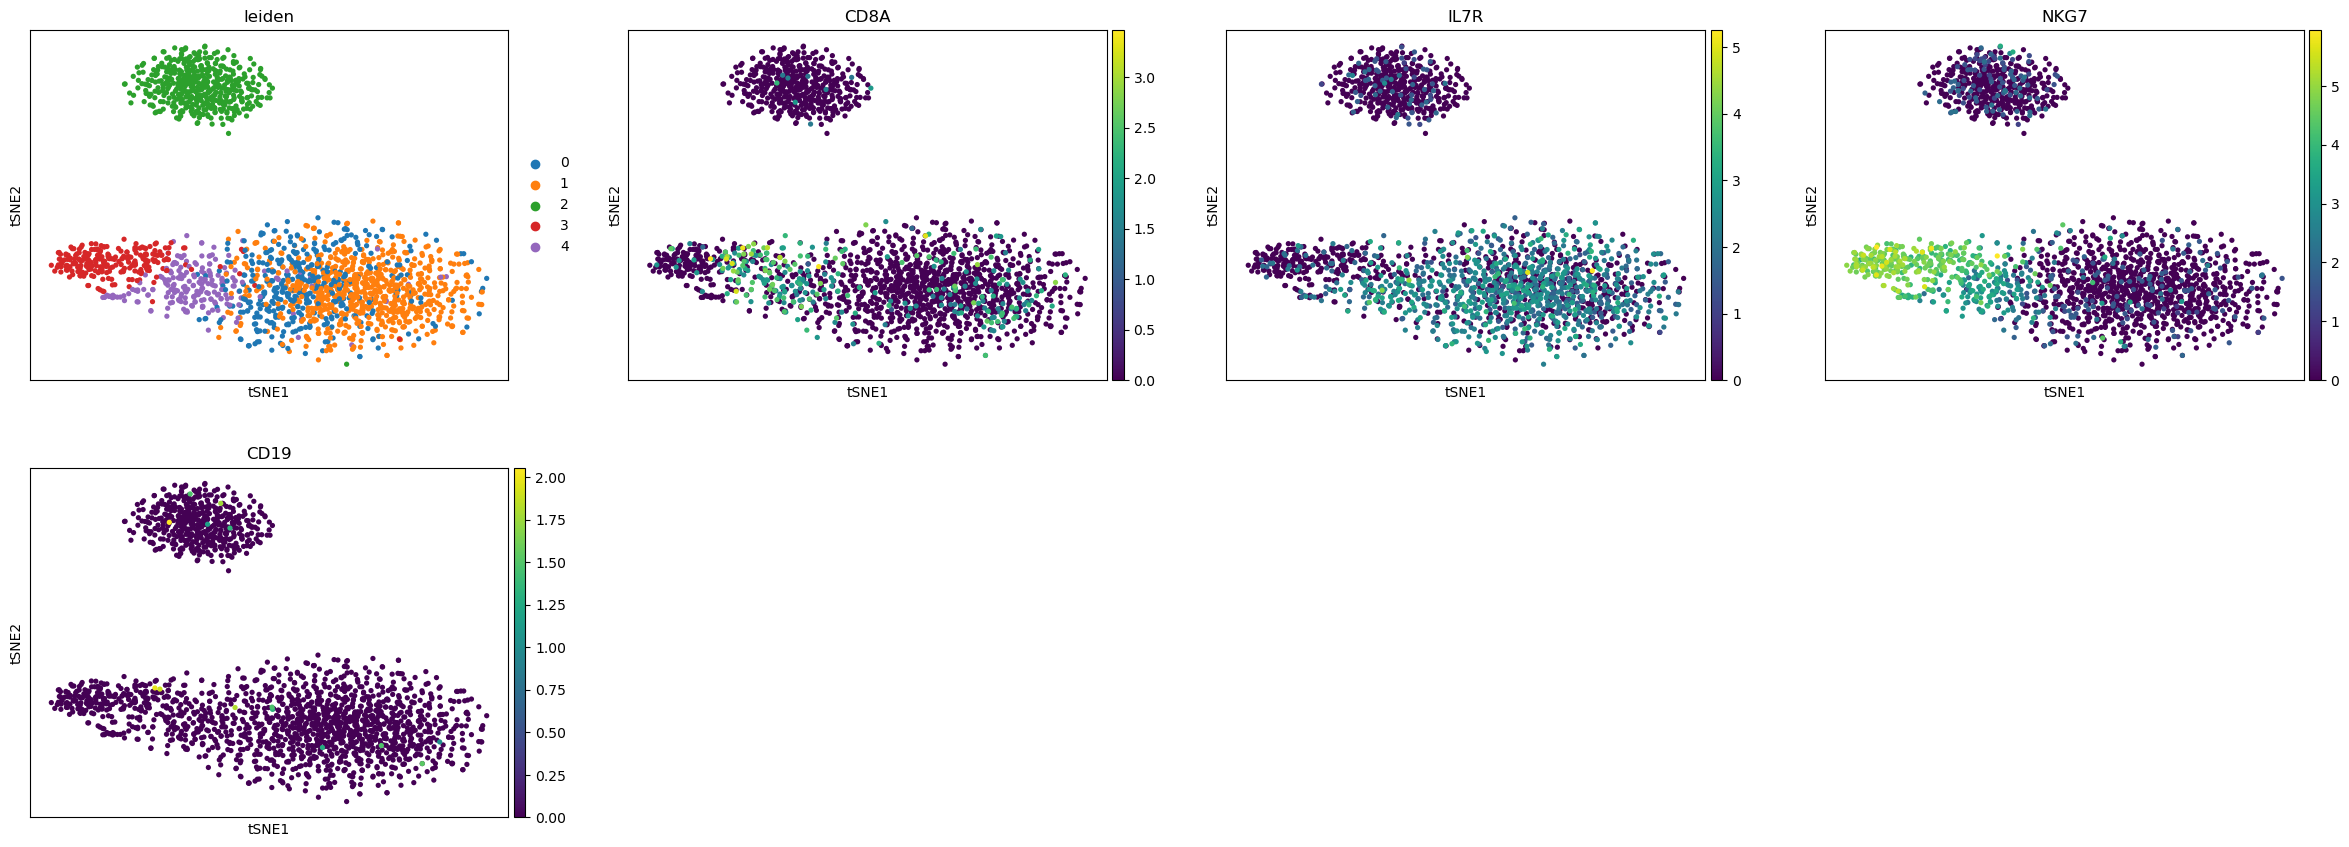

In [65]:
# compute t-SNE
sc.tl.tsne(subset_pbmc_scrnaseq, perplexity = 30)

# Plot the clusters using leiden clustering and visualize t-SNE and key T cell marker genes
sc.pl.tsne(subset_pbmc_scrnaseq, color = ["leiden", 'CD8A', "IL7R", "NKG7", "CD19"])

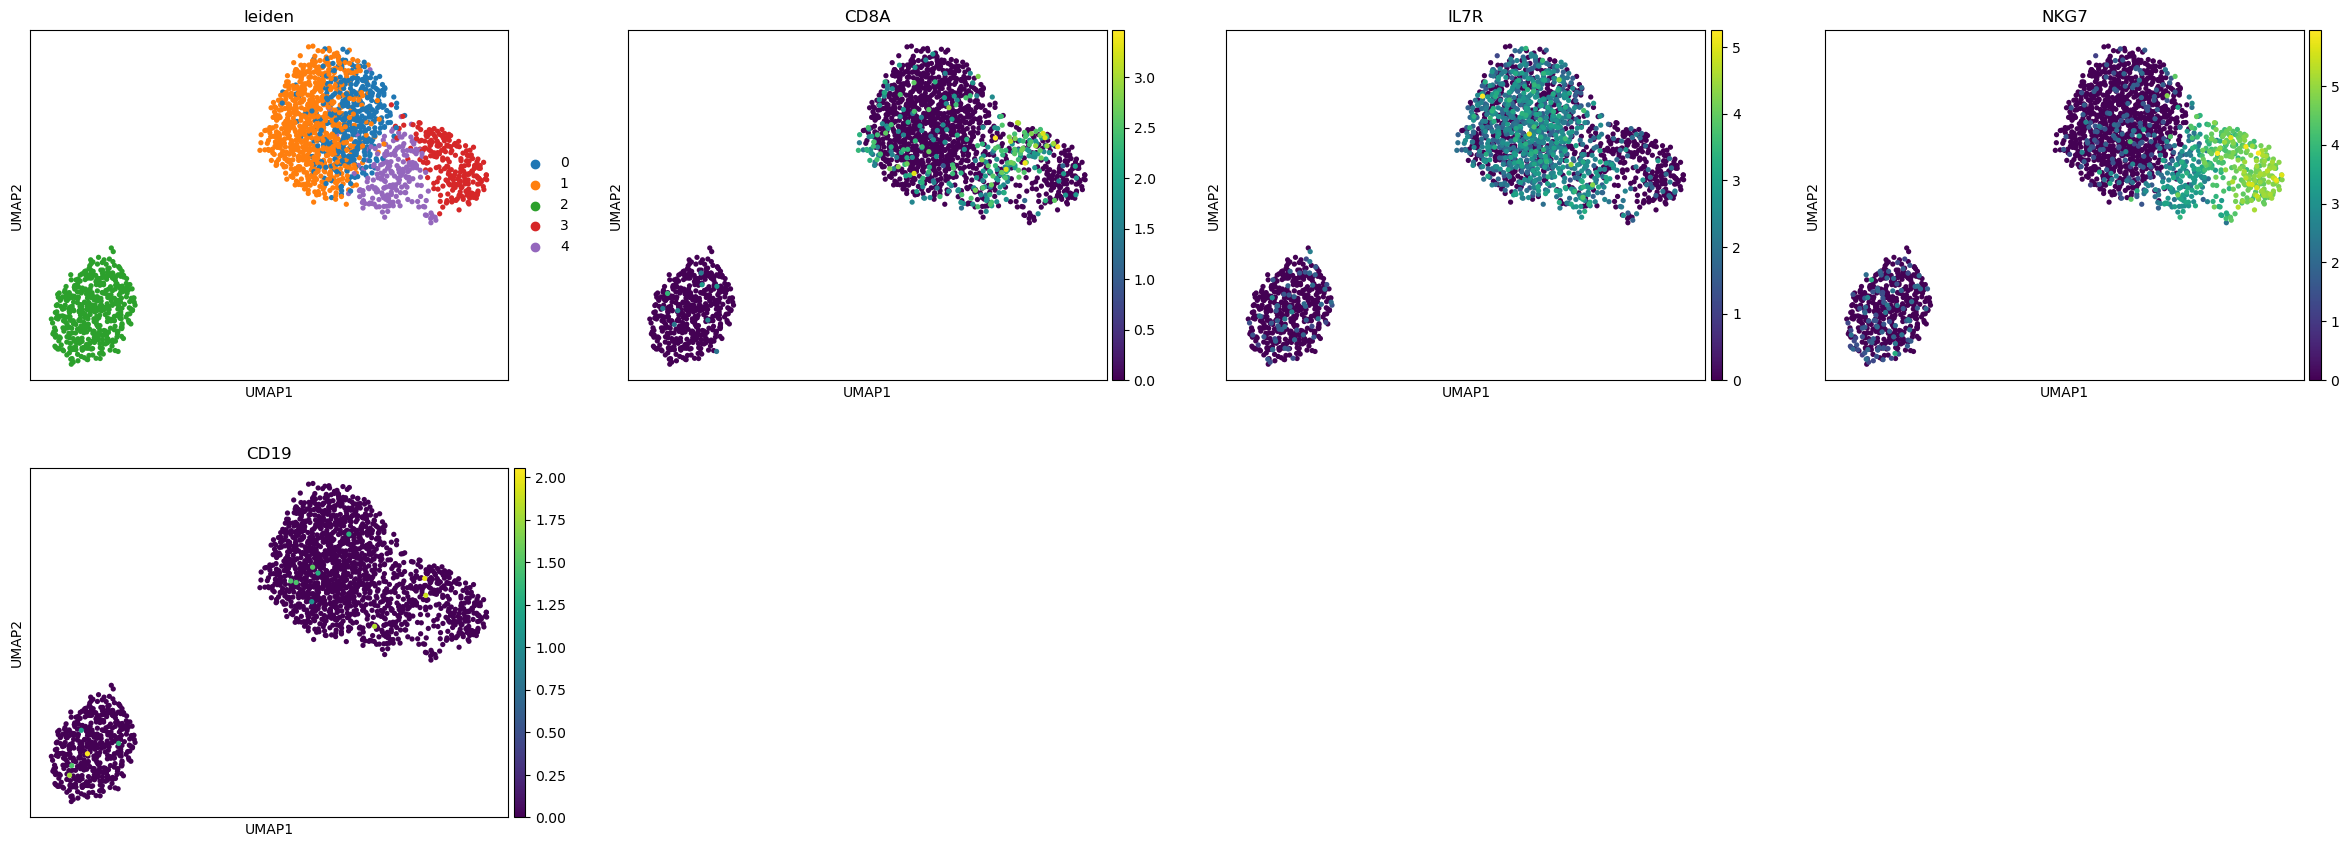

In [66]:
# Compute UMAP
sc.tl.umap(subset_pbmc_scrnaseq)

# Plot the clusters using leiden clustering and visualize UMAP and key T cell marker genes
sc.pl.umap(subset_pbmc_scrnaseq, color=["leiden", 'CD8A', "IL7R", "NKG7", "CD19"])